#Data Cleaning and Reporting Automation

Dataset Loading and Inspection

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [34]:
df = pd.read_csv("animal_data.csv", sep=";")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 1011
Columns: 11


In [35]:
df.head()

,Animal type,Country,Weight kg,Body Length cm,Gender,Animal code,Latitude,Longitude,Animal name,Observation date,Data compiled by
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,03.01.2024,James Johnson
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,03.02.2024,James Johnson
2,European bison,Poland,930.0,335.0,male,NaN,52.828845,23.820144,Szefu,01.03.2024,Anne Anthony
3,European bison,Poland,909.0,311.0,not determined,NaN,52.830509,23.826849,NaN,01.03.2024,Anne Anthony
4,European bison™,Poland,581.0,277.0,female,NaN,52.834109,23.807093,NaN,01.03.2024,Anne Anthony


In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1011 entries, 0 to 1010
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Animal type       991 non-null    object 
 1   Country           999 non-null    object 
 2   Weight kg         984 non-null    float64
 3   Body Length cm    984 non-null    float64
 4   Gender            992 non-null    object 
 5   Animal code       0 non-null      float64
 6   Latitude          913 non-null    float64
 7   Longitude         913 non-null    float64
 8   Animal name       52 non-null     object 
 9   Observation date  1011 non-null   object 
 10  Data compiled by  1011 non-null   object 
dtypes: float64(5), object(6)
memory usage: 87.0+ KB


Missing Value Analysis

In [37]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Animal type           20
Country               12
Weight kg             27
Body Length cm        27
Gender                19
Animal code         1011
Latitude              98
Longitude             98
Animal name          959
Observation date       0
Data compiled by       0
dtype: int64


Duplicate Record Detection and Removal

In [38]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 167


In [39]:
df = df.drop_duplicates()

print("Rows after removing duplicates:", df.shape[0])
print("Duplicate rows remaining:", df.duplicated().sum())

Rows after removing duplicates: 844
Duplicate rows remaining: 0


In [40]:
# Handle missing values column by column

# Numerical columns
df["Weight kg"] = df["Weight kg"].fillna(df["Weight kg"].median())
df["Body Length cm"] = df["Body Length cm"].fillna(df["Body Length cm"].median())
df["Latitude"] = df["Latitude"].fillna(df["Latitude"].median())
df["Longitude"] = df["Longitude"].fillna(df["Longitude"].median())

# Categorical columns
df["Animal type"] = df["Animal type"].fillna("Unknown")
df["Country"] = df["Country"].fillna("Unknown")
df["Gender"] = df["Gender"].fillna("Unknown")
df["Animal code"] = df["Animal code"].fillna("Unknown")
df["Animal name"] = df["Animal name"].fillna("Unknown")
df["Observation date"] = df["Observation date"].fillna("Unknown")
df["Data compiled by"] = df["Data compiled by"].fillna("Unknown")

print("Missing values handled successfully!")
print("Total missing values:", df.isnull().sum().sum())

Missing values handled successfully!
Total missing values: 0


In [41]:
# Handle invalid negative values

df.loc[df["Weight kg"] < 0, "Weight kg"] = np.nan
df.loc[df["Body Length cm"] < 0, "Body Length cm"] = np.nan

# Fill invalid values with the median
df["Weight kg"] = df["Weight kg"].fillna(df["Weight kg"].median())
df["Body Length cm"] = df["Body Length cm"].fillna(df["Body Length cm"].median())

print("Invalid negative values handled successfully!")

Invalid negative values handled successfully!


In [42]:
# Data Validation

print("Data Validation")
print("----------------")

print("Negative weights:", (df["Weight kg"] < 0).sum())
print("Negative body lengths:", (df["Body Length cm"] < 0).sum())
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Data Validation
----------------
Negative weights: 0
Negative body lengths: 0
Missing values: 0
Duplicate rows: 0


In [43]:
# Final Data Verification

print("Final Data Verification")
print("-----------------------")

print("Final number of rows:", df.shape[0])
print("Final number of columns:", df.shape[1])
print("Missing values remaining:", df.isnull().sum().sum())
print("Duplicate rows remaining:", df.duplicated().sum())

Final Data Verification
-----------------------
Final number of rows: 844
Final number of columns: 11
Missing values remaining: 0
Duplicate rows remaining: 0


In [44]:
print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
Animal type         0
Country             0
Weight kg           0
Body Length cm      0
Gender              0
Animal code         0
Latitude            0
Longitude           0
Animal name         0
Observation date    0
Data compiled by    0
dtype: int64


Data Standardization

In [45]:
for column in df.select_dtypes(include="object").columns:
    print("\n", column)
    print(df[column].value_counts().head(20))


 Animal type
Animal type
red squirrel       387
hedgehog           274
lynx                61
European bison      49
Unknown             19
red squirrell       16
red squirel         10
lynx?               10
European bison™      6
European buster      4
European bisson      4
ledgehod             3
wedgehod             1
Name: count, dtype: int64

 Country
Country
Poland            182
Germany           173
Slovakia          151
Czech Republic    103
Hungary           103
Austria            74
Unknown            11
PL                 10
HU                  8
Hungry              7
CZ                  5
DE                  5
Czech               4
Australia           4
CC                  4
Name: count, dtype: int64

 Gender
Gender
male              423
female            401
Unknown            15
not determined      5
Name: count, dtype: int64

 Animal code
Animal code
Unknown    844
Name: count, dtype: int64

 Animal name
Animal name
Unknown       806
Bob Bobson     18
Basia           

In [46]:
# Standardize inconsistent animal type values

animal_type_mapping = {
    "red squirrell": "red squirrel",
    "red squirel": "red squirrel",
    "lynx?": "lynx",
    "European bison™": "European bison",
    "European buster": "European bison",
    "European bisson": "European bison",
    "ledgehod": "hedgehog",
    "wedgehod": "hedgehog"
}

df["Animal type"] = df["Animal type"].replace(animal_type_mapping)

print("Animal type values after cleaning:")
print(df["Animal type"].value_counts())

Animal type values after cleaning:
Animal type
red squirrel      413
hedgehog          278
lynx               71
European bison     63
Unknown            19
Name: count, dtype: int64


In [47]:
country_mapping = {
    "PL": "Poland",
    "HU": "Hungary",
    "Hungry": "Hungary",
    "CZ": "Czech Republic",
    "Czech": "Czech Republic",
    "DE": "Germany",
    "CC": "Unknown"
}

df["Country"] = df["Country"].replace(country_mapping)

print("Country values after cleaning:")
print(df["Country"].value_counts())

Country values after cleaning:
Country
Poland            192
Germany           178
Slovakia          151
Hungary           118
Czech Republic    112
Austria            74
Unknown            15
Australia           4
Name: count, dtype: int64


In [48]:
gender_mapping = {
    "male": "Male",
    "female": "Female",
    "not determined": "Unknown"
}

df["Gender"] = df["Gender"].replace(gender_mapping)

print("Gender values after cleaning:")
print(df["Gender"].value_counts())

Gender values after cleaning:
Gender
Male       423
Female     401
Unknown     20
Name: count, dtype: int64


Date Format Conversion

In [49]:
# Convert observation date to proper date format
df["Observation date"] = pd.to_datetime(
    df["Observation date"],
    format="%d.%m.%Y",
    errors="coerce"
)

# Fill missing or invalid dates with the most frequent date
df["Observation date"] = df["Observation date"].fillna(
    df["Observation date"].mode()[0]
)

print("Observation date converted and missing dates handled successfully!")
print("Missing dates:", df["Observation date"].isnull().sum())
print("Data type:", df["Observation date"].dtype)

Observation date converted and missing dates handled successfully!
Missing dates: 0
Data type: datetime64[ns]


Final Data Verification

In [50]:
print("Final rows:", df.shape[0])
print("Final columns:", df.shape[1])

print("\nMissing values:")
print(df.isnull().sum())

print("\nTotal missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Final rows: 844
Final columns: 11

Missing values:
Animal type         0
Country             0
Weight kg           0
Body Length cm      0
Gender              0
Animal code         0
Latitude            0
Longitude           0
Animal name         0
Observation date    0
Data compiled by    0
dtype: int64

Total missing values: 0
Duplicate rows: 2


In [51]:
# Remove any duplicate records remaining after cleaning
df = df.drop_duplicates()

print("Duplicate records removed successfully!")
print("Duplicate rows remaining:", df.duplicated().sum())

Duplicate records removed successfully!
Duplicate rows remaining: 0


In [52]:
print("Cleaned Dataset Summary")
print("-----------------------")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Duplicate rows:", df.duplicated().sum())
print("Total missing values:", df.isnull().sum().sum())

Cleaned Dataset Summary
-----------------------
Rows: 842
Columns: 11
Duplicate rows: 0
Total missing values: 0


Data Visualization

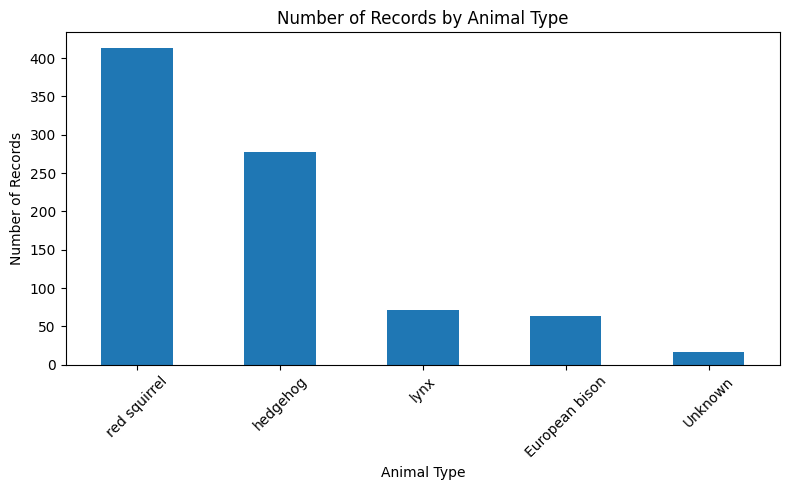

In [53]:
plt.figure(figsize=(8, 5))

df["Animal type"].value_counts().plot(kind="bar")

plt.title("Number of Records by Animal Type")
plt.xlabel("Animal Type")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

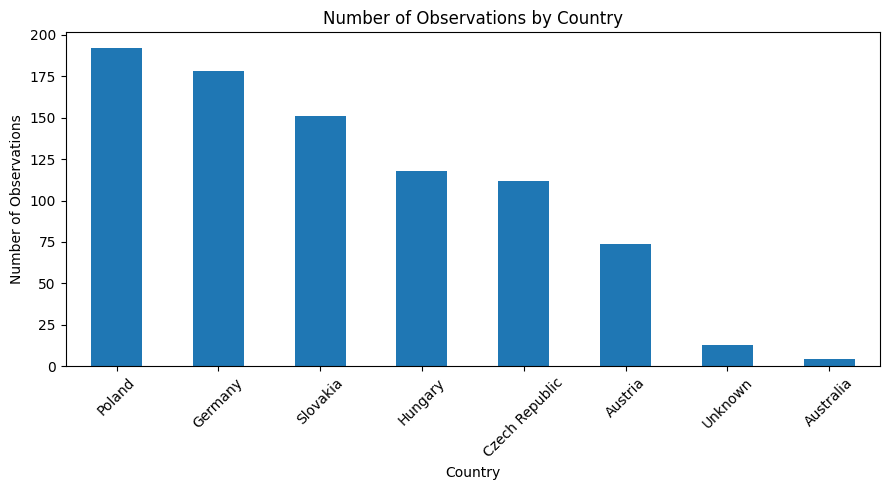

In [54]:
plt.figure(figsize=(9, 5))

df["Country"].value_counts().plot(kind="bar")

plt.title("Number of Observations by Country")
plt.xlabel("Country")
plt.ylabel("Number of Observations")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

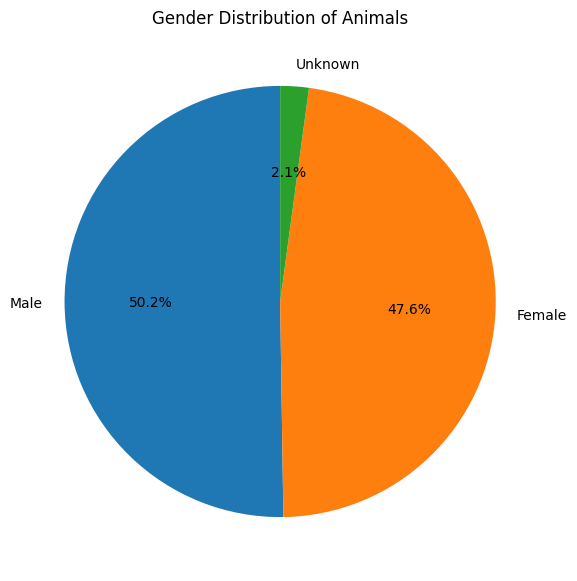

In [55]:
gender_counts = df["Gender"].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Gender Distribution of Animals")
plt.show()

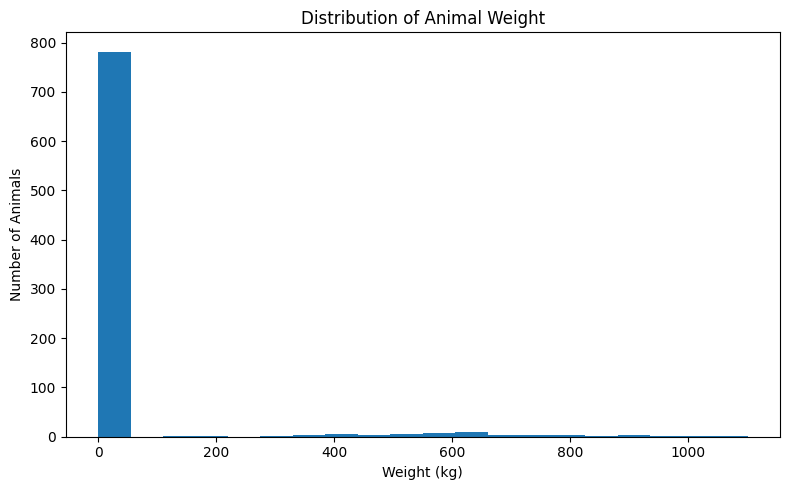

In [56]:
plt.figure(figsize=(8, 5))

plt.hist(df["Weight kg"], bins=20)

plt.title("Distribution of Animal Weight")
plt.xlabel("Weight (kg)")
plt.ylabel("Number of Animals")
plt.tight_layout()
plt.show()

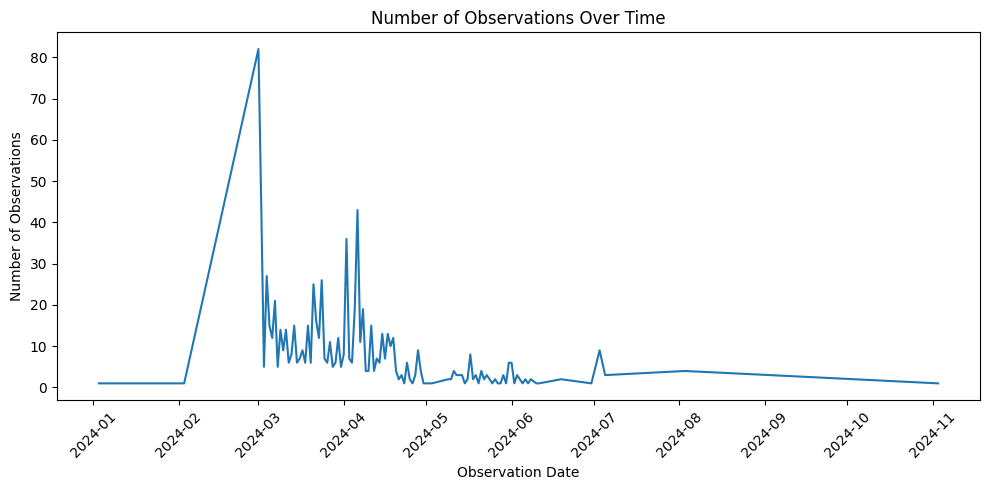

In [57]:
# Count observations for each date
date_counts = df["Observation date"].value_counts().sort_index()

plt.figure(figsize=(10, 5))

plt.plot(date_counts.index, date_counts.values)

plt.title("Number of Observations Over Time")
plt.xlabel("Observation Date")
plt.ylabel("Number of Observations")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Summary Report

In [58]:
summary_report = pd.DataFrame({
    "Metric": [
        "Total Records",
        "Total Columns",
        "Duplicate Records",
        "Missing Values",
        "Animal Types",
        "Countries",
        "Gender Categories"
    ],
    "Value": [
        len(df),
        len(df.columns),
        df.duplicated().sum(),
        df.isnull().sum().sum(),
        df["Animal type"].nunique(),
        df["Country"].nunique(),
        df["Gender"].nunique()
    ]
})

summary_report

,Metric,Value
0,Total Records,842
1,Total Columns,11
2,Duplicate Records,0
3,Missing Values,0
4,Animal Types,5
5,Countries,8
6,Gender Categories,3


Report Export

In [59]:
df.to_csv("cleaned_animal_data.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [60]:
with pd.ExcelWriter("Data_Cleaning_Report.xlsx") as writer:
    df.to_excel(writer, sheet_name="Cleaned Data", index=False)
    summary_report.to_excel(writer, sheet_name="Summary Report", index=False)

    missing_report = pd.DataFrame({
        "Column": df.columns,
        "Missing Values": df.isnull().sum().values
    })
    missing_report.to_excel(writer, sheet_name="Missing Values", index=False)

print("Automated Excel report created successfully!")

Automated Excel report created successfully!


Output File Verification

In [61]:
import os

print("Cleaned CSV exists:", os.path.exists("cleaned_animal_data.csv"))
print("Excel report exists:", os.path.exists("Data_Cleaning_Report.xlsx"))

Cleaned CSV exists: True
Excel report exists: True


In [62]:
from google.colab import files

files.download("cleaned_animal_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [63]:
from google.colab import files

files.download("Data_Cleaning_Report.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>